In [ ]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import FastSAM
import time

# --- Configurations ---
dummy_point = [200, 700]  # Pixel to target [x, y]
image_path = 'sa_2.jpg'
json_path = 'sa_2.json'

print("1. Loading Image & GT Data...")
img = cv2.imread(image_path)
if img is None: raise ValueError(f"Could not load {image_path}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
original_shape = img.shape[:2]

actual_mask = np.zeros(original_shape, dtype=np.uint8)
try:
    with open(json_path, 'r') as f:
        data = json.load(f)
        px, py = dummy_point
        min_area = float('inf')
        for ann in data.get('annotations', []):
            seg = ann['segmentation']
            if isinstance(seg, dict):
                h, w = seg['size']
                counts = seg['counts']
                if isinstance(counts, list):
                    mask_1d = np.zeros(h * w, dtype=np.uint8)
                    pos = 0
                    for j, count in enumerate(counts):
                        if j % 2 == 1: mask_1d[pos : pos + count] = 1
                        pos += count
                    seg_mask = mask_1d.reshape((w, h)).T
                else:
                    from pycocotools import mask as maskUtils
                    seg_mask = maskUtils.decode(seg)
            else: seg_mask = np.array(seg, dtype=np.uint8)

            if py < seg_mask.shape[0] and px < seg_mask.shape[1] and seg_mask[py, px] > 0:
                area = ann.get('area', np.sum(seg_mask))
                if area < min_area:
                    min_area = area
                    actual_mask = seg_mask.copy()
    print("   -> Success: Image and Ground Truth loaded.")
except Exception as e:
    print(f"   -> Error loading JSON: {e}")

# Load FastSAM Model once
model = FastSAM("FastSAM-x.pt")

1. Loading Image & GT Data...
   -> Success: Image and Ground Truth loaded.


In [20]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian

print("4 & 5. Running FastSAM + Active Contour Refinement...")
# Initial Inference
results = model(image_path, points=[dummy_point], labels=[1])

if results[0].masks is not None:
    # Get initial mask
    fastsam_mask_raw = results[0].masks.data.cpu().numpy()[0]
    fastsam_mask = cv2.resize(fastsam_mask_raw, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_NEAREST)
    
    start_time = time.time()
    
    # --- SNAKE REFINEMENT ---
    # 1. Convert mask to boundary points (coordinates)
    contours, _ = cv2.findContours(fastsam_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    init_pts = contours[0].reshape(-1, 2)
    
    # 2. Smooth the guide image slightly to remove noise
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    
    # 3. Evolve the snake
    # alpha: snake continuity (stretching), beta: snake smoothness (bending)
    snake = active_contour(gaussian(img_gray, 3, preserve_range=False),
                           init_pts, alpha=0.015, beta=10, gamma=0.001)
    
    # 4. Convert snake back to a binary mask
    refined_mask = np.zeros(original_shape, dtype=np.uint8)
    cv2.fillPoly(refined_mask, [snake.astype(np.int32)], 1)
    
    method_name = "Active Contours (Snakes)"
    print(f"   -> {method_name} completed in {time.time() - start_time:.4f} seconds.")
else:
    print("❌ No FastSAM mask found.")

4 & 5. Running FastSAM + Active Contour Refinement...

image 1/1 d:\sems\AIP\Proj\code\sa_2.jpg: 704x1024 1 object, 125.7ms
Speed: 4.6ms preprocess, 125.7ms inference, 21.7ms postprocess per image at shape (1, 3, 704, 1024)
   -> Active Contours (Snakes) completed in 2.5074 seconds.


6 & 7. Plotting Comparison...


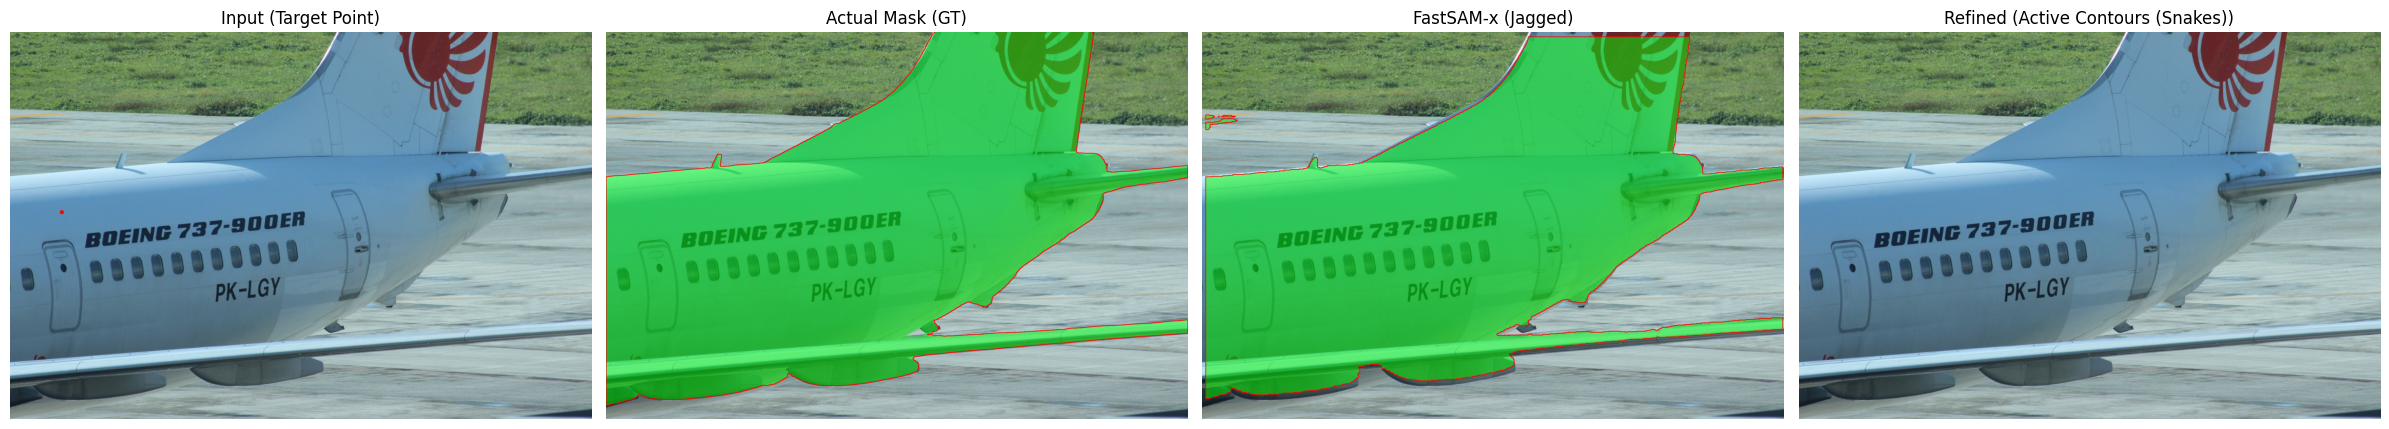

In [21]:
def create_overlay(img_base, mask, mask_color=(0, 255, 0), boundary_color=(255, 0, 0)):
    mask_bin = (mask > 0.5).astype(np.uint8)
    color_layer = np.zeros_like(img_base)
    color_layer[:] = mask_color
    alpha = mask[..., None] * 0.5 
    overlay = (img_base * (1 - alpha) + color_layer * alpha).astype(np.uint8)
    cnts, _ = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, cnts, -1, boundary_color, 2)
    return overlay

print("6 & 7. Plotting Comparison...")
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Input
inp_plot = img_rgb.copy()
cv2.circle(inp_plot, (dummy_point[0], dummy_point[1]), 8, (255, 0, 0), -1)
axes[0].imshow(inp_plot); axes[0].set_title("Input (Target Point)"); axes[0].axis('off')

# GT
axes[1].imshow(create_overlay(img_rgb, actual_mask)); axes[1].set_title("Actual Mask (GT)"); axes[1].axis('off')

# FastSAM
axes[2].imshow(create_overlay(img_rgb, fastsam_mask)); axes[2].set_title("FastSAM-x (Jagged)"); axes[2].axis('off')

# Refined
axes[3].imshow(create_overlay(img_rgb, refined_mask)); axes[3].set_title(f"Refined ({method_name})"); axes[3].axis('off')

plt.tight_layout()
plt.savefig('refinement_test.png', dpi=300)
plt.show()